<a href="https://colab.research.google.com/github/isaactaj/eda-spotify-2025/blob/main/spotify_explicit_2025_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória: O Impacto do Conteúdo Explícito na Popularidade Musical no Spotify

**Dataset:** Spotify Global 2025 (8.582 músicas, 2.548 artistas)  
**Autor:** Isaac Trindade  
**Stack:** Google BigQuery (SQL), Python (Pandas, Matplotlib), Google Colab  

## 1. Objetivo e Metodologia

Investigar se a classificação de conteúdo explícito (`explicit`) atua como um fator de impulsionamento na popularidade das faixas no Spotify. Para garantir consistência, a hipótese foi testada em três camadas:
1. Comparação macro (todas as faixas).
2. Segmentação pelo tamanho do artista (Emerging, Mid, Top).
3. Análise intra-artista em casos de uso massivo vs. cirúrgico.

**Metodologia:** Toda a manipulação pesada de dados foi executada no Google BigQuery via SQL. Este notebook atua apenas como cliente de orquestração: ele envia as queries para o BigQuery e utiliza o Python estritamente para visualização de dados e documentação dos insights.

## 2. TL;DR (Resumo Executivo)
* **Hipótese validada:** Faixas explícitas apresentam popularidade média 14% maior de forma consistente em todos os portes de artistas.
* **Uso estratégico:** Artistas emergentes utilizam menos conteúdo explícito proporcionalmente, mas colhem o maior retorno relativo quando o fazem.
* **Qualidade > Volume:** Métricas compostas revelam que rankings baseados apenas em volume de faixas explícitas criam falsos positivos de engajamento atual.

In [3]:
# Autenticação com conta Google que tem acesso ao projeto
from google.colab import auth
auth.authenticate_user()

print("✓ Autenticado com sucesso")

✓ Autenticado com sucesso


In [4]:
# Imports
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Configuração visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Função auxiliar para arredondamento clássico (half-up)
def round_half_up(x):
    """Arredondamento clássico: 0.5 sempre sobe."""
    return math.floor(x + 0.5)

# Cliente BigQuery
PROJECT_ID = "spotify-eda-2025"
client = bigquery.Client(project=PROJECT_ID)

print(f"Cliente BigQuery conectado ao projeto: {PROJECT_ID}")

Cliente BigQuery conectado ao projeto: spotify-eda-2025


In [5]:
# Teste de conexão (Garante que consegue ler a tabela)
test_query = """
SELECT COUNT(*) AS total_musicas
FROM `spotify-eda-2025.spotify_global_2025.tracks_clean`
"""
client.query(test_query).to_dataframe()

,total_musicas
0,8582


---
## 3. Análise Macro: Explícito vs Não-Explícito

**Pergunta de Negócio:** No panorama geral, faixas com o selo `explicit = VERDADEIRO` geram mais popularidade média?

Para responder, comparamos o volume, a média e a dispersão (desvio padrão) da popularidade entre os dois grupos.

,explicit,total_musicas,popularidade_media,desvio_padrao
0,FALSO,6434,50.5,24.0
1,VERDADEIRO,2148,57.8,22.2


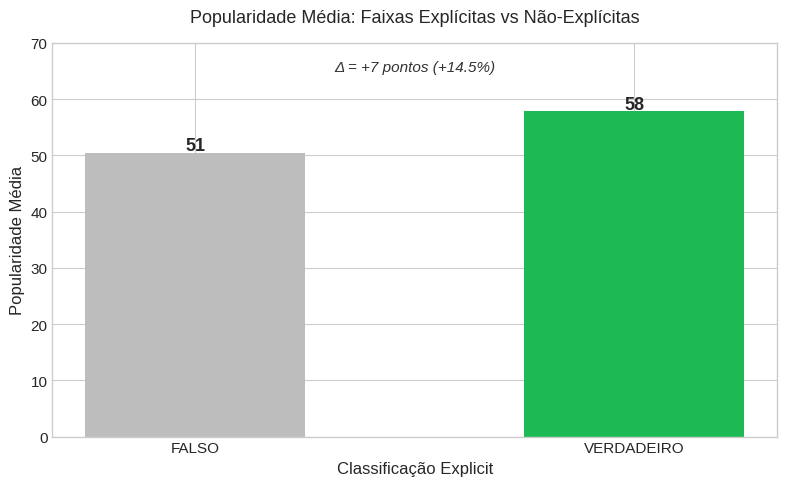

In [6]:
query_01 = """
SELECT
  explicit,
  COUNT(*) AS total_musicas,
  ROUND(AVG(track_popularity), 1) AS popularidade_media,
  ROUND(STDDEV(track_popularity), 1) AS desvio_padrao
FROM `spotify-eda-2025.spotify_global_2025.tracks_clean`
GROUP BY explicit
ORDER BY explicit
"""

df_01 = client.query(query_01).to_dataframe()
display(df_01)

# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#BDBDBD', '#1DB954']
bars = ax.bar(df_01['explicit'], df_01['popularidade_media'], color=colors, width=0.5)

for bar, valor in zip(bars, df_01['popularidade_media']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{round_half_up(valor)}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Popularidade Média', fontsize=12)
ax.set_xlabel('Classificação Explicit', fontsize=12)
ax.set_title('Popularidade Média: Faixas Explícitas vs Não-Explícitas', fontsize=13, pad=15)
ax.set_ylim(0, 70)

# Cálculo e exibição do Delta
delta = df_01.iloc[1]['popularidade_media'] - df_01.iloc[0]['popularidade_media']
delta_pct = (delta / df_01.iloc[0]['popularidade_media']) * 100
ax.text(0.5, 65, f'Δ = +{round_half_up(delta)} pontos (+{delta_pct:.1f}%)',
        ha='center', fontsize=11, style='italic', color='#333')

plt.tight_layout()
plt.show()

> **Insight 1** > A hipótese foi validada no escopo macro. Faixas explícitas apresentam popularidade média **14,4% superior** (57,8 vs 50,5). Curiosamente, o desvio padrão é ligeiramente menor no grupo explícito (22,2 vs 24,0), sugerindo que o retorno de engajamento desse tipo de conteúdo é não apenas maior, mas também mais previsível. Apesar de representarem apenas 25% do catálogo total, geram performance superior consistente.


---
## 4. Análise por Estrato de Artista (Tiers)

**Pergunta de Negócio:** O padrão macro é puxado apenas pelos gigantes da indústria, ou se mantém transversalmente em todos os níveis de popularidade do artista?

Segmentamos os artistas por quartis de seguidores (`Emerging`, `Mid`, `Top`).

,artist_tier,explicit,total_musicas,popularidade_media
0,Emerging,FALSO,4088,46.0
1,Emerging,VERDADEIRO,911,51.6
2,Mid,FALSO,1470,56.7
3,Mid,VERDADEIRO,825,60.6
4,Top,FALSO,876,61.4
5,Top,VERDADEIRO,412,66.1


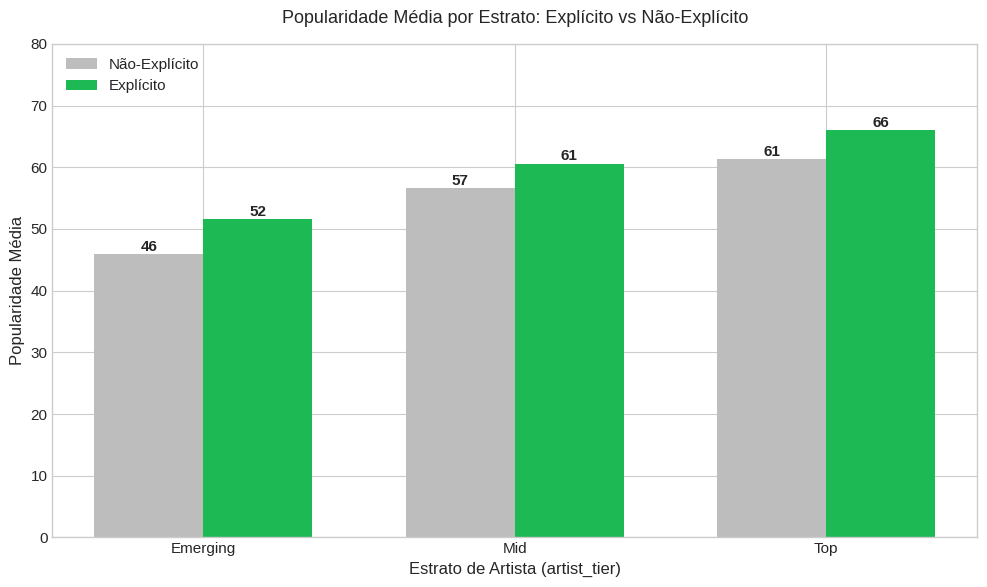

In [7]:
query_02 = """
SELECT
  artist_tier,
  explicit,
  COUNT(*) AS total_musicas,
  ROUND(AVG(track_popularity), 1) AS popularidade_media
FROM `spotify-eda-2025.spotify_global_2025.tracks_clean`
GROUP BY artist_tier, explicit
ORDER BY
  CASE artist_tier
    WHEN 'Emerging' THEN 1
    WHEN 'Mid' THEN 2
    WHEN 'Top' THEN 3
    ELSE 4
  END,
  explicit
"""

df_02 = client.query(query_02).to_dataframe()

# Exibe a tabela interativa antes do gráfico
display(df_02)

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
tier_order = ['Emerging', 'Mid', 'Top']
df_02_pivot = df_02.pivot(index='artist_tier', columns='explicit', values='popularidade_media').reindex(tier_order)

x = np.arange(len(tier_order))
width = 0.35

bars_falso = ax.bar(x - width/2, df_02_pivot['FALSO'], width, label='Não-Explícito', color='#BDBDBD')
bars_verd = ax.bar(x + width/2, df_02_pivot['VERDADEIRO'], width, label='Explícito', color='#1DB954')

for bar, valor in zip(bars_falso, df_02_pivot['FALSO']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{round_half_up(valor)}', ha='center', fontsize=11, fontweight='bold')

for bar, valor in zip(bars_verd, df_02_pivot['VERDADEIRO']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{round_half_up(valor)}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Estrato de Artista (artist_tier)', fontsize=12)
ax.set_ylabel('Popularidade Média', fontsize=12)
ax.set_title('Popularidade Média por Estrato: Explícito vs Não-Explícito', fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_ylim(0, 80)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

> **Insight 2** > O padrão se mantém positivamente em todos os tiers. Porém, há um detalhe comportamental: artistas **Emerging usam muito menos conteúdo explícito** em proporção (18% do catálogo vs ~34% nos outros tiers), mas quando utilizam, registram o **maior ganho relativo (+13%)**. Isso sugere que o conteúdo explícito atua como uma forte alavanca de tração em estágios iniciais de carreira.


---
## 5. Análise Intra-Artista: O Efeito no Mesmo Catálogo

**Pergunta de Negócio:** Dentro da discografia de um mesmo artista top de mercado, a faixa explícita performa melhor?

Selecionamos três gigantes com perfis criativos distintos para testar: Drake, Bad Bunny e Taylor Swift.

explicit,FALSO,VERDADEIRO,total,% explicitas
artist_name,,,,
Drake,11,73,84,86.9
Taylor Swift,278,46,324,14.2
Bad Bunny,11,45,56,80.4


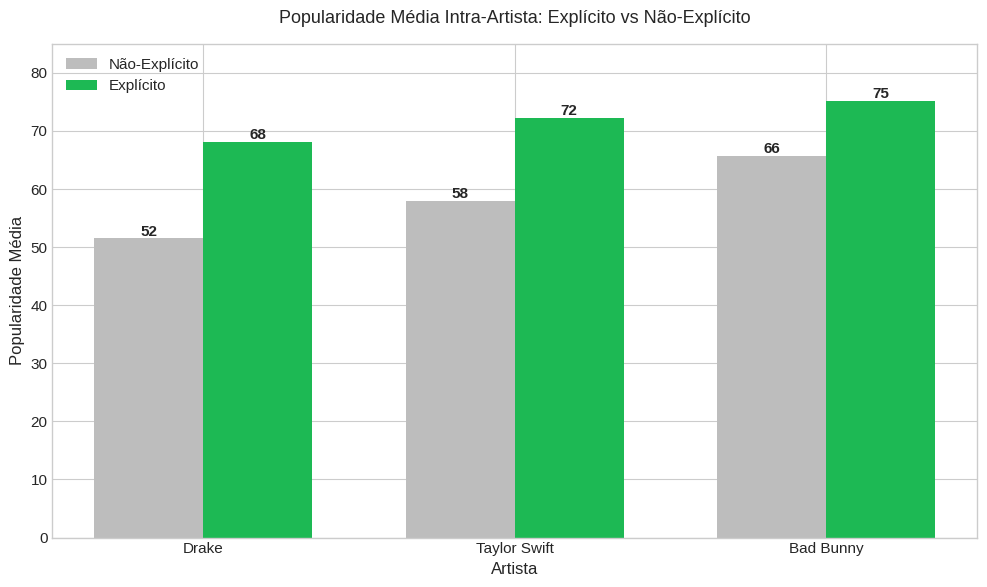

In [8]:
query_03 = """
SELECT
  artist_name,
  explicit,
  COUNT(*) AS total_musicas,
  ROUND(AVG(track_popularity), 1) AS popularidade_media
FROM `spotify-eda-2025.spotify_global_2025.tracks_clean`
WHERE artist_name IN ('Drake', 'Taylor Swift', 'Bad Bunny')
GROUP BY artist_name, explicit
ORDER BY artist_name, explicit
"""

df_03 = client.query(query_03).to_dataframe()

# Cálculo de proporção no catálogo
artistas_order = ['Drake', 'Taylor Swift', 'Bad Bunny']
df_03_pivot_counts = df_03.pivot(index='artist_name', columns='explicit', values='total_musicas').reindex(artistas_order)
df_03_pivot_counts['total'] = df_03_pivot_counts['FALSO'] + df_03_pivot_counts['VERDADEIRO']
df_03_pivot_counts['% explicitas'] = round((df_03_pivot_counts['VERDADEIRO'] / df_03_pivot_counts['total']) * 100, 1)

display(df_03_pivot_counts)

# Visualização
df_03_pivot = df_03.pivot(index='artist_name', columns='explicit', values='popularidade_media').reindex(artistas_order)
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(artistas_order))
width = 0.35

bars_falso = ax.bar(x - width/2, df_03_pivot['FALSO'], width, label='Não-Explícito', color='#BDBDBD')
bars_verd = ax.bar(x + width/2, df_03_pivot['VERDADEIRO'], width, label='Explícito', color='#1DB954')

for bar, valor in zip(bars_falso, df_03_pivot['FALSO']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{round_half_up(valor)}', ha='center', fontsize=11, fontweight='bold')

for bar, valor in zip(bars_verd, df_03_pivot['VERDADEIRO']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{round_half_up(valor)}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Artista', fontsize=12)
ax.set_ylabel('Popularidade Média', fontsize=12)
ax.set_title('Popularidade Média Intra-Artista: Explícito vs Não-Explícito', fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(artistas_order)
ax.set_ylim(0, 85)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

> **Insight 3** > O padrão se isola de fatores externos e se comprova em nível individual: em todos os três casos, a faixa explícita é mais popular. O grande achado é a diferença na **estratégia de uso**. Drake e Bad Bunny têm um uso massivo (87% e 80% do catálogo). Taylor Swift faz um uso cirúrgico (apenas 14%), mas quando apropria-se do selo explícito, tem um salto imenso de popularidade (+14 pontos absolutos).

---
## 6. O Ranking Real: Volume vs Relevância

**Pergunta de Negócio:** Quem domina o catálogo explícito hoje?

Rankings puramente baseados em *volume* beneficiam catálogos inflados ou de artistas do passado. Para encontrar os verdadeiros líderes de mercado atuais, criamos um **Score Composto** (`Total de Faixas Explícitas × Popularidade Média`).

rank,artist_name,artist_followers,total_explicitas,popularidade_media,score_volume_x_popularidade
1,Drake,103126025,73,68.100000,4969.000000
2,The Weeknd,113039308,70,60.600000,4240.000000
3,Eminem,104584370,66,56.500000,3732.000000
4,Post Malone,47726839,59,60.700000,3582.000000
5,Bad Bunny,102610644,45,75.200000,3384.000000
6,Taylor Swift,145542136,46,72.300000,3325.000000
7,Playboi Carti,15037198,45,64.700000,2912.000000
8,Ariana Grande,107418606,39,66.000000,2574.000000
9,Lil Peep,15702014,59,42.800000,2526.000000
10,Travis Scott,41131037,30,70.500000,2115.000000


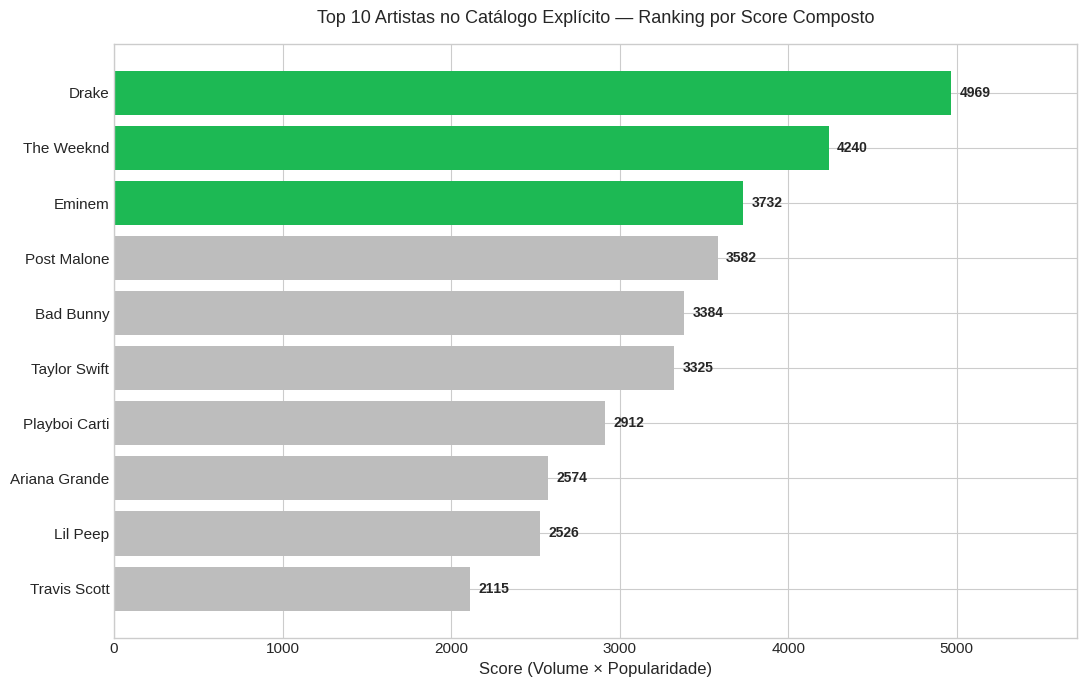

In [10]:
query_04 = """
SELECT
  artist_name,
  MAX(artist_followers) AS artist_followers,
  COUNT(*) AS total_explicitas,
  ROUND(AVG(track_popularity), 1) AS popularidade_media,
  ROUND(COUNT(*) * AVG(track_popularity), 0) AS score_volume_x_popularidade
FROM `spotify-eda-2025.spotify_global_2025.tracks_clean`
WHERE explicit = 'VERDADEIRO'
GROUP BY artist_name
ORDER BY score_volume_x_popularidade DESC
LIMIT 10
"""

df_04 = client.query(query_04).to_dataframe()
df_04.insert(0, 'rank', range(1, len(df_04) + 1))
display(df_04.style.hide(axis='index'))

# Visualização
fig, ax = plt.subplots(figsize=(11, 7))
df_04_sorted = df_04.sort_values('score_volume_x_popularidade', ascending=True)
colors = ['#1DB954' if i >= len(df_04_sorted) - 3 else '#BDBDBD' for i in range(len(df_04_sorted))]

bars = ax.barh(df_04_sorted['artist_name'], df_04_sorted['score_volume_x_popularidade'], color=colors)

for bar, valor in zip(bars, df_04_sorted['score_volume_x_popularidade']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{int(valor)}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Score (Volume × Popularidade)', fontsize=12)
ax.set_title('Top 10 Artistas no Catálogo Explícito — Ranking por Score Composto', fontsize=13, pad=15)
ax.set_xlim(0, df_04_sorted['score_volume_x_popularidade'].max() * 1.15)

plt.tight_layout()
plt.show()

>**Insight 4** > A métrica composta ajustou perfeitamente as distorções do ranking. Lil Peep (que possuía alto volume mas baixa popularidade por inatividade desde 2017) despencou do 5º lugar no volume puro para a margem do Top 10. Marilyn Manson saiu do Top 10 e caiu para 20º. Artistas com catálogos focados e altíssimo engajamento, como Bad Bunny e Post Malone, assumiram o protagonismo correto.

---
## 7. Conclusões Finais e Próximos Passos

A análise cumpriu seu objetivo e provou, em múltiplas camadas, que o selo `explicit` não é apenas um marcador passivo, mas um ativo de engajamento no Spotify.

**Resumo Analítico:**
1. **Padrão Transversal:** +14% de popularidade média global, efeito mantido independentemente do porte do artista.
2. **Alavanca de Crescimento:** Artistas emergentes colhem mais retorno relativo de faixas explícitas do que veteranos.
3. **Contraste de Estratégias:** O conteúdo explícito serve tanto para domínio de nicho (uso massivo) quanto para quebra de expectativa e hype (uso cirúrgico, ex: Taylor Swift).

**Limitações:**
* A popularidade reflete o engajamento atual no Spotify, ignorando histórico de vendas físicas ou impacto cultural passado.
* A análise não isola o gênero musical. O alto uso de explícito em Hip-Hop vs. o baixo uso em Pop pode ser uma variável de confusão que influencia as médias.

**Próximos Passos Sugeridos:**
* Executar uma regressão ou segmentação por gênero (`artist_genres`) para isolar se a alta do explícito é mérito da tag em si ou apenas reflexo do domínio atual do rap/trap.
* Análise de série temporal (`album_release_date`) para entender se a aceitação do conteúdo explícito aumentou nos últimos anos.